In [1]:
import os
import glob
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

def extract_windows(emg, label, window_size, step):
    windows, labels = [], []
    for i in range(0, len(emg) - window_size, step):
        window = emg[i:i + window_size]
        win_label = np.bincount(label[i:i + window_size].flatten()).argmax()
        windows.append(window)
        labels.append(win_label)
    return np.array(windows), np.array(labels)

from scipy.signal import butter, lfilter, iirnotch

# ==========================================
#  Processing Filters
# ==========================================
def apply_emg_filters(emg_data, fs=2000.0):
    """
    fs=2000.0 لأن تردد التقاط البيانات في NinaPro DB2 هو 2000 هرتز
    """
    # 1. Notch Filter (50 Hz) لإزالة شوشرة الكهرباء
    w0 = 50.0 / (fs / 2.0)
    Q = 30.0
    b_notch, a_notch = iirnotch(w0, Q)
    emg_filtered = lfilter(b_notch, a_notch, emg_data, axis=0)
    
    # 2. Bandpass Filter (20-500 Hz) لإزالة حركة الجلد والضوضاء العالية
    low = 20.0 / (fs / 2.0)
    high = 500.0 / (fs / 2.0)
    b_band, a_band = butter(4, [low, high], btype='band')
    emg_filtered = lfilter(b_band, a_band, emg_filtered, axis=0)
    
    return emg_filtered

def apply_lowpass_envelope(emg_data, fs=2000.0, cutoff=10.0):
    """
    Low-pass filter لتنعيم الإشارة بعد أخذ القيمة المطلقة (Envelope)
    """
    normal_cutoff = cutoff / (fs / 2.0)
    b_low, a_low = butter(4, normal_cutoff, btype='low', analog=False)
    envelope = lfilter(b_low, a_low, emg_data, axis=0)
    return envelope

# ==========================================
#  load_ninapro_task
# ==========================================
def load_ninapro_task(base_path, allowed_classes, subjects, allowed_reps, train_reps=[1,3,4,6], window_size=400, step=40, num_channels=12, mu=255.0):
    all_x, all_y = [], []
    for subj in subjects:
        search_pattern = os.path.join(base_path, '**', f'S{subj}_E2*.mat')
        file_paths = glob.glob(search_pattern, recursive=True)
        for file_path in file_paths:
            try:
                data = sio.loadmat(file_path)
                emg = data['emg'][:, :num_channels]
                labels = data['restimulus'].flatten()
                reps = data['repetition'].flatten()

                #  [التعديل هنا] تطبيق الفلاتر الأساسية أولاً
                emg = apply_emg_filters(emg, fs=2000.0)

                # العمليات الرياضية لفك التداخل (Crosstalk)
                emg = np.abs(emg)
                
                #  [التعديل هنا] استخراج غلاف الإشارة الناعم (Envelope)
                emg = apply_lowpass_envelope(emg, fs=2000.0, cutoff=10.0)
                
                # إرجاع القيم السلبية إن وجدت بسبب الفلتر ثم تطبيق اللوغاريتم
                emg = np.clip(emg, a_min=0, a_max=None)
                emg = np.log1p(mu * emg) / np.log1p(mu)
                
                scaler = StandardScaler()
                train_mask = np.isin(reps, train_reps)
                if np.any(train_mask):
                    scaler.fit(emg[train_mask])
                    emg = scaler.transform(emg)
                else:
                    emg = scaler.fit_transform(emg)

                unique_reps = np.unique(reps)
                for r in unique_reps:
                    if r not in allowed_reps:
                        continue
                    for c in allowed_classes:
                        segment_mask = (labels == c) & (reps == r)
                        if not np.any(segment_mask):
                            continue
                            
                        segment_emg = emg[segment_mask]
                        segment_label = labels[segment_mask]
                        
                        # ==========================================
                        #  التعديل الجديد: Transition Cropping
                        # ==========================================
                        if c != 0: # لا نقص وضع الراحة (0)
                            margin = int(len(segment_emg) * 0.15) # قص 15% من البداية والنهاية
                            if len(segment_emg) > (2 * margin + window_size):
                                segment_emg = segment_emg[margin:-margin]
                                segment_label = segment_label[margin:-margin]
                        # ==========================================
                                
                        if len(segment_emg) >= window_size:
                            x_wins, y_wins = extract_windows(segment_emg, segment_label, window_size, step)
                            all_x.append(x_wins)
                            all_y.append(y_wins)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    if not all_x:
        return np.array([]), np.array([])

    X = np.concatenate(all_x, axis=0)
    Y = np.concatenate(all_y, axis=0).astype(np.int64)
    return X, Y

def balance_classes(X, Y):
    classes, counts = np.unique(Y, return_counts=True)
    print(f"  Before Balancing : {dict(zip(classes, counts))}")
    rest_idx = np.where(Y == 0)[0]
    move_idx = np.where(Y != 0)[0]
    if len(move_idx) > 0 and len(rest_idx) > 0:
        target_rest = int(np.mean([c for cls, c in zip(classes, counts) if cls != 0]))
        if len(rest_idx) > target_rest:
            np.random.seed(42)
            sel_rest = np.random.choice(rest_idx, target_rest, replace=False)
            final_idx = np.concatenate([sel_rest, move_idx])
            np.random.shuffle(final_idx)
            X, Y = X[final_idx], Y[final_idx]
            nc, ncounts = np.unique(Y, return_counts=True)
            print(f"  After Balancing : {dict(zip(nc, ncounts))}")
    return X, Y
# ==========================================
# إعدادات المسارات وتقسيم المرضى
# ==========================================
TRAIN_DIR = '/kaggle/input/datasets/farahellabban/ninapro-db2'
TARGET_DIR = '/kaggle/input/datasets/farahellabban/ninapro-db2'

PRETRAIN_SUBJECTS = [1, 2, 3, 4]
TARGET_SUBJECT = [5]

# ==========================================
# 1. بيانات الـ Pretrain: المرضى الـ 4 الأوائل
# ==========================================
print("\nLoading Pretrain Data (4 subjects, 12 classes from E2)...")
e2_all_classes = [0] + list(range(18, 29)) 

X_pre_train, Y_pre_train = load_ninapro_task(TRAIN_DIR, e2_all_classes, PRETRAIN_SUBJECTS, [1,3,4,6], num_channels=12)
X_pre_val,   Y_pre_val   = load_ninapro_task(TRAIN_DIR, e2_all_classes, PRETRAIN_SUBJECTS, [2,5], num_channels=12)

X_pre_train, Y_pre_train = balance_classes(X_pre_train, Y_pre_train)
X_pre_val,   Y_pre_val   = balance_classes(X_pre_val, Y_pre_val)

def make_loader(X, Y, batch_size=64, shuffle=True):
    # لاحظي: البيانات أصبحت نظيفة وموحدة مسبقاً، نرسلها مباشرة للـ Tensor
    return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y)), batch_size=batch_size, shuffle=shuffle)

pretrain_loader = make_loader(X_pre_train, Y_pre_train)
pretrain_val_loader = make_loader(X_pre_val, Y_pre_val, shuffle=False)

# ==========================================
# 2. بيانات المريض الخامس (Subject 5)
# ==========================================
print("\nLoading Subject 5 - Task 1 (Base Classes: 0 and 18 to 24)...")
task1_classes = [0, 18, 19, 20, 21, 22, 23, 24]
X_t1_train, Y_t1_train = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [1,3,4,6], step=10, num_channels=12)
X_t1_test,  Y_t1_test  = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [2,5], step=10, num_channels=12)

print("Loading Subject 5 - Task 2 (Novel Classes: 0 and 25 to 28)...")
task2_classes = [0, 25, 26, 27, 28]
X_t2_train, Y_t2_train = load_ninapro_task(TARGET_DIR, task2_classes, TARGET_SUBJECT, [1,3,4,6], step=10, num_channels=12)
X_t2_test,  Y_t2_test  = load_ninapro_task(TARGET_DIR, task2_classes, TARGET_SUBJECT, [2,5], step=10, num_channels=12)

X_t1_train, Y_t1_train = balance_classes(X_t1_train, Y_t1_train)
X_t2_train, Y_t2_train = balance_classes(X_t2_train, Y_t2_train)

t1_train_loader = make_loader(X_t1_train, Y_t1_train)
t1_test_loader  = make_loader(X_t1_test, Y_t1_test, shuffle=False)
t2_train_loader = make_loader(X_t2_train, Y_t2_train)
t2_test_loader  = make_loader(X_t2_test, Y_t2_test, shuffle=False)


t1_train_loader = make_loader(X_t1_train, Y_t1_train)
t1_test_loader  = make_loader(X_t1_test, Y_t1_test, shuffle=False)
t2_train_loader = make_loader(X_t2_train, Y_t2_train)
t2_test_loader  = make_loader(X_t2_test, Y_t2_test, shuffle=False)


print("\n Incremental Learning for (Subject 1)  ")
X_s1_train, Y_s1_train = load_ninapro_task(TRAIN_DIR, e2_all_classes, [1], [1,3,4,6], num_channels=12, window_size=400, step=40)
X_s1_val,   Y_s1_val   = load_ninapro_task(TRAIN_DIR, e2_all_classes, [1], [2,5], num_channels=12, window_size=400, step=40)



X_s1_train, Y_s1_train = balance_classes(X_s1_train, Y_s1_train)
X_s1_val,   Y_s1_val   = balance_classes(X_s1_val, Y_s1_val)

s1_train_loader = make_loader(X_s1_train, Y_s1_train)
s1_val_loader = make_loader(X_s1_val, Y_s1_val, shuffle=False)


Loading Pretrain Data (4 subjects, 12 classes from E2)...
  Before Balancing : {np.int64(0): np.int64(16872), np.int64(18): np.int64(2340), np.int64(19): np.int64(2106), np.int64(20): np.int64(2263), np.int64(21): np.int64(1965), np.int64(22): np.int64(2361), np.int64(23): np.int64(2289), np.int64(24): np.int64(2715), np.int64(25): np.int64(2428), np.int64(26): np.int64(2667), np.int64(27): np.int64(2084), np.int64(28): np.int64(2364)}
  After Balancing : {np.int64(0): np.int64(2325), np.int64(18): np.int64(2340), np.int64(19): np.int64(2106), np.int64(20): np.int64(2263), np.int64(21): np.int64(1965), np.int64(22): np.int64(2361), np.int64(23): np.int64(2289), np.int64(24): np.int64(2715), np.int64(25): np.int64(2428), np.int64(26): np.int64(2667), np.int64(27): np.int64(2084), np.int64(28): np.int64(2364)}
  Before Balancing : {np.int64(0): np.int64(7784), np.int64(18): np.int64(1220), np.int64(19): np.int64(1086), np.int64(20): np.int64(1081), np.int64(21): np.int64(1102), np.int64

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, 3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out) * x

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, gru_output):
        attention_weights = self.attention(gru_output)
        attention_weights = F.softmax(attention_weights, dim=1)
        context_vector = torch.sum(attention_weights * gru_output, dim=1)
        return context_vector

class Metric_ContinualNet(nn.Module):
    def __init__(self, embedding_dim=32, proj_dim=128, num_sensors=12):
        super(Metric_ContinualNet, self).__init__()
        
        # ==============================================================
        #  التعديل الأول: بوابة الانتباه الحسي المبكر (Input Sensor Attention)
        # ==============================================================
        # تتعلم أي الحساسات (الـ 12) مهمة لهذه الحركة وتُسكت الحساسات المزعجة
        self.sensor_attention = nn.Sequential(
            nn.Linear(num_sensors, num_sensors),
            nn.Sigmoid()
        )
        
        # ==============================================================
        #  التعديل الثاني: الفلاتر المتمددة (Dilated Multi-Scale)
        # ==============================================================
        # المسار 1: زوم عالي جداً للرعشات (طبيعي بدون تمدد)
        self.branch1 = nn.Conv2d(1, 4, kernel_size=(1, 15), stride=(1, 4), padding=(0, 7))
        
        # المسار 2: زوم متوسط (فلتر حجم 9، لكن يتمدد بمقدار 4 ليغطي مساحة 33)
        self.branch2 = nn.Conv2d(1, 4, kernel_size=(1, 9), stride=(1, 4), dilation=(1, 4), padding=(0, 16))
        
        # المسار 3: زوم واسع (فلتر حجم 9، لكن يتمدد بمقدار 8 ليغطي مساحة 65)
        self.branch3 = nn.Conv2d(1, 8, kernel_size=(1, 9), stride=(1, 4), dilation=(1, 8), padding=(0, 32))
        # (استخدام الفلاتر المتمددة قلل الأوزان وزاد وضوح الرؤية للإشارات المتباعدة)
        
        self.bn_temp = nn.BatchNorm2d(16)
        
        
        self.depthwise = nn.Conv2d(16, 32, kernel_size=(3, 3), padding=0, groups=16)
        self.pointwise = nn.Conv2d(32, 32, kernel_size=1)
        self.bn_spat = nn.BatchNorm2d(32)
        
        self.ca = ChannelAttention(32)
        self.sa = SpatialAttention()
        
        self.pool = nn.MaxPool2d(kernel_size=(2, 4))
        self.dropout = nn.Dropout(0.4) 
        
        s_new = num_sensors // 2 
        gru_input_dim = 32 * s_new 
        
        self.gru = nn.GRU(
            input_size=gru_input_dim, 
            hidden_size=64,  
            num_layers=1, 
            batch_first=True
        )
        self.temporal_attention = TemporalAttention(64)
        
        self.embedding_head = nn.Sequential(
            nn.Linear(64, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, embedding_dim) 
        )

        self.projection_head = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, proj_dim) 
        )

        self.regression_head = nn.Sequential(
            nn.Linear(64, 32), 
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, W, S = x.shape
        
        #  تفعيل بوابة الانتباه الحسي قبل أي معالجة
        # نحسب متوسط طاقة كل حساس عبر الزمن، ونمررها لشبكة صغيرة لتقييم أهمية الحساس
        sensor_importance = self.sensor_attention(x.mean(dim=1)) # شكلها (B, S)
        # نضرب كل حساس في نسبة أهميته (الحساس المزعج سيُضرب في رقم قريب من 0)
        x = x * sensor_importance.unsqueeze(1) 
        
        x = x.permute(0, 2, 1).contiguous()
        x = x.unsqueeze(1)
        
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        
        x = torch.cat([b1, b2, b3], dim=1) 
        x = F.relu(self.bn_temp(x))
        
        x = F.pad(x, (1, 1, 0, 0), mode='constant', value=0) 
        x = F.pad(x, (0, 0, 1, 1), mode='circular')          
        
        x = self.depthwise(x)
        x = F.relu(self.bn_spat(self.pointwise(x)))
        x = self.ca(x)
        x = self.sa(x)
        
        x = self.pool(x)
        x = self.dropout(x)
        
        B, C, S_new, T_new = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, T_new, C * S_new)
        
        gru_out, _ = self.gru(x)
        features = self.temporal_attention(gru_out)
        
        base_embeddings = self.embedding_head(features)
        proj_embeddings = self.projection_head(base_embeddings)
        
        base_embeddings = F.normalize(base_embeddings, p=2, dim=1)
        proj_embeddings = F.normalize(proj_embeddings, p=2, dim=1)
        
        force = self.regression_head(features)
        
        return proj_embeddings, base_embeddings, force

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07): 
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        features = F.normalize(features, p=2, dim=1)
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)
        
        mask = torch.eq(labels, labels.T).float().to(device)
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
        
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()
        
        logits_mask = torch.scatter(
            torch.ones_like(mask), 1, torch.arange(batch_size, device=device).view(-1, 1), 0
        )
        mask = mask * logits_mask
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)
        loss = -mean_log_prob_pos
        valid_mask = (mask.sum(1) > 0)
        
        return loss[valid_mask].mean() if valid_mask.sum() > 0 else loss.mean()

@torch.no_grad()
def prototype_accuracy(model, support_loader, query_loader, device, max_support_batches=60):
    model.eval()
    embs, lbls = [], []
    
    # 1. بناء الـ Prototypes من بيانات التدريب (Support)
    for b, (x, y) in enumerate(support_loader):
        if b >= max_support_batches: break
        _, base, _ = model(x.to(device))
        embs.append(base.cpu())
        lbls.append(y)
        
    embs = torch.cat(embs)
    lbls = torch.cat(lbls)
    keys = torch.unique(lbls).tolist()
    
    protos = torch.stack([embs[lbls == k].mean(0) for k in keys])
    protos = F.normalize(protos, p=2, dim=1).to(device)
    keys_t = torch.tensor(keys, device=device)

    # 2. تقييم بيانات الاختبار/التحقق (Query) بناءً على مراكز التدريب
    correct = total = 0
    for x, y in query_loader:
        _, base, _ = model(x.to(device))
        dists = torch.cdist(base, protos)
        pred = keys_t[dists.argmin(1)]
        correct += (pred == y.to(device)).sum().item()
        total += y.size(0)
        
    return 100.0 * correct / max(1, total)

import copy

def train_supcon_phase1(model, train_loader, val_loader, epochs=70, lr=0.001, device='cuda'):
    criterion = SupConLoss(temperature=0.07) 
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    
    #  التعديل هنا: الـ Scheduler يراقب الـ Accuracy ويرتفع معها
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    
    print("\n [Phase 1] Training with Strict Validation & Channel-wise Warping...")
    
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        train_samples = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            #  التعديل هنا: Warping لكل حساس (قناة) بشكل مستقل
            warp_factor = torch.empty(inputs.shape[0], 1, inputs.shape[2]).uniform_(0.8, 1.2).to(device)
            augmented_inputs = inputs * warp_factor
            noise = torch.randn_like(augmented_inputs) * 0.01
            augmented_inputs = augmented_inputs + noise
            
            optimizer.zero_grad()
            proj_emb, base_emb, _ = model(augmented_inputs)
            loss = criterion(proj_emb, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
            train_samples += inputs.size(0)
            
        epoch_train_loss = running_train_loss / max(1, train_samples)
        
        #  التعديل الجذري: استخدام الدالة الصادقة لحساب الدقة
        val_accuracy = prototype_accuracy(model, train_loader, val_loader, device)
            
        scheduler.step(val_accuracy) # الـ Scheduler يتخذ قراره بناءً على الدقة الصادقة
        
        marker = ""
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            best_model_wts = copy.deepcopy(model.state_dict())
            marker = " (New High!)"
            
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:02d}/{epochs}] | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} | True Val Acc: {val_accuracy:.2f}% {marker}")
        
    print(f"\n Phase 1 Completed! Best True Validation Accuracy: {best_val_acc:.2f}%")
    model.load_state_dict(best_model_wts)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# نبدأ الموديل من الصفر (بأوزان نظيفة)
metric_model = Metric_ContinualNet(embedding_dim=32, proj_dim=128, num_sensors=12).to(device)

print("\n=======================================================")
print("Phase 1: Constructing model on (Subject1) ")
print("=======================================================")
# التدريب على المريض الأول فقط، لكي يرسم خريطة نظيفة لحركات اليد
metric_model = train_supcon_phase1(
    metric_model, 
    s1_train_loader,      
    s1_val_loader,  
    epochs=30, 
    lr=0.001, 
    device=device
)

print("\n=======================================================")
print("Phase 2: Generalizng on the (4 subjects)")
print("=======================================================")

metric_model = train_supcon_phase1(
    metric_model, 
    pretrain_loader,      # DataLoader اللي فيه الـ 4 مرضى
    pretrain_val_loader,  
    epochs=40, 
    lr=0.0005, # قللنا الـ LR للنصف لكي لا نهدم ما تعلمه الموديل في المرحلة السابقة
    device=device
)


Phase 1: Constructing model on (Subject1) 

 [Phase 1] Training with Strict Validation & Channel-wise Warping...
Epoch [01/30] | LR: 0.001000 | Train Loss: 3.5738 | True Val Acc: 66.46%  (New High!)
Epoch [02/30] | LR: 0.001000 | Train Loss: 2.8951 | True Val Acc: 75.14%  (New High!)
Epoch [03/30] | LR: 0.001000 | Train Loss: 2.6786 | True Val Acc: 77.32%  (New High!)
Epoch [04/30] | LR: 0.001000 | Train Loss: 2.5230 | True Val Acc: 81.30%  (New High!)
Epoch [05/30] | LR: 0.001000 | Train Loss: 2.4439 | True Val Acc: 84.40%  (New High!)
Epoch [06/30] | LR: 0.001000 | Train Loss: 2.3775 | True Val Acc: 85.96%  (New High!)
Epoch [07/30] | LR: 0.001000 | Train Loss: 2.3077 | True Val Acc: 85.89% 
Epoch [08/30] | LR: 0.001000 | Train Loss: 2.2564 | True Val Acc: 86.99%  (New High!)
Epoch [09/30] | LR: 0.001000 | Train Loss: 2.2395 | True Val Acc: 86.44% 
Epoch [10/30] | LR: 0.001000 | Train Loss: 2.1868 | True Val Acc: 85.49% 
Epoch [11/30] | LR: 0.001000 | Train Loss: 2.1712 | True Val A

In [9]:
import torch.nn.functional as F

@torch.no_grad()
def adapt_bn(model, loader, device):
    model.eval()
    bns = [m for m in model.modules() if isinstance(m, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d))]
    for m in bns:
        m.reset_running_stats()
        m.momentum = None
        m.train() 
    for x, _ in loader:
        model(x.to(device))
    for m in bns:
        m.momentum = 0.1
    model.eval()
    return model

def compute_class_prototypes(model, dataloader, device='cuda'):
    model.eval()
    class_embeddings = {}
    with torch.no_grad():
        for inputs, labels in dataloader:
            _, base_emb, _ = model(inputs.to(device)) 
            for i, label in enumerate(labels.cpu().numpy()):
                if label not in class_embeddings: class_embeddings[label] = []
                class_embeddings[label].append(base_emb[i].cpu())
                
    prototypes = {}
    for label, embs in class_embeddings.items():
        stacked_embs = torch.stack(embs)
        proto_mean = stacked_embs.mean(dim=0)
        prototypes[label] = F.normalize(proto_mean.unsqueeze(0), p=2, dim=1).squeeze(0).to(device)
    return prototypes

def collect(model, loader, prototypes, device='cuda'):
    model.eval()
    all_preds, all_true, all_dist = [], [], []
    sorted_keys = sorted(prototypes.keys())
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)

    with torch.no_grad():
        for x, y in loader:
            _, embeddings, _ = model(x.to(device))
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            min_dist, pred_indices = torch.min(distances, dim=1)
            
            preds = [sorted_keys[idx] for idx in pred_indices.cpu().numpy()]
            all_preds.extend(preds)
            all_true.extend(y.numpy())
            all_dist.extend(min_dist.cpu().numpy())
            
    return np.array(all_preds), np.array(all_true), np.array(all_dist)

def causal_majority_vote(pred, true, k):
    out = pred.copy()
    seg_start = 0
    for i in range(len(pred)):
        if i > 0 and true[i] != true[i-1]: 
            seg_start = i 
        out[i] = np.bincount(pred[max(seg_start, i-k+1): i+1]).argmax()
    return out

In [6]:
import copy
from sklearn.metrics import balanced_accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(" [1] STARTING CORRECTED ABLATION STUDY ")
print("-" * 60)

# تجهيز الموديل الأساسي (Backbone)
src_model = copy.deepcopy(metric_model)
adapt_bn(src_model, pretrain_loader, device)

def evaluate_condition(name, use_adabn, cal_loader, test_loader=t1_test_loader):
    model = copy.deepcopy(src_model)
    if hasattr(model, 'gru'): model.gru.flatten_parameters() # لمنع تحذير الـ RNN
    
    if use_adabn: adapt_bn(model, cal_loader, device)
        
    protos = compute_class_prototypes(model, cal_loader, device=device)
    p, t, _ = collect(model, test_loader, protos, device)
    
    mv = t != 0
    bal_acc = 100 * balanced_accuracy_score(t, p)
    move_acc = 100 * np.mean(p[mv] == t[mv])
    false_act = 100 * np.mean(p[t == 0] != 0)
    
    print(f"{name:20s} | Balanced: {bal_acc:.2f}% | Movement: {move_acc:.2f}% | False-Act: {false_act:.2f}%")
    return p, t 

evaluate_condition("Prototypes only (Raw)", False, t1_train_loader)
pred_for_smoothing, true_for_smoothing = evaluate_condition("AdaBN + Prototypes", True, t1_train_loader)

print("\n [2] SMOOTHING EFFECT (Segment-Aware) ")
print("-" * 60)
for k in [1, 5, 10, 20, 40, 80]:
    ps = causal_majority_vote(pred_for_smoothing, true_for_smoothing, k)
    mv = true_for_smoothing != 0
    delay_ms = (k-1) * (10 / 2000) * 1000 
    print(f"k={k:2d} (+{delay_ms:3.0f} ms delay) | Move Acc: {100 * np.mean(ps[mv] == true_for_smoothing[mv]):.2f}% | False-Act: {100 * np.mean(ps[true_for_smoothing == 0] != 0):.2f}%")

 [1] STARTING CORRECTED ABLATION STUDY 
------------------------------------------------------------


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/rnn.py:1449: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Prototypes only (Raw) | Balanced: 57.48% | Movement: 49.95% | False-Act: 11.63%
AdaBN + Prototypes   | Balanced: 60.35% | Movement: 57.03% | False-Act: 10.11%

 [2] SMOOTHING EFFECT (Segment-Aware) 
------------------------------------------------------------
k= 1 (+  0 ms delay) | Move Acc: 57.03% | False-Act: 10.11%
k= 5 (+ 20 ms delay) | Move Acc: 57.11% | False-Act: 10.06%
k=10 (+ 45 ms delay) | Move Acc: 57.29% | False-Act: 9.79%
k=20 (+ 95 ms delay) | Move Acc: 57.84% | False-Act: 9.65%
k=40 (+195 ms delay) | Move Acc: 58.99% | False-Act: 8.87%
k=80 (+395 ms delay) | Move Acc: 59.65% | False-Act: 7.46%


In [14]:
import torch.optim as optim
from copy import deepcopy
import numpy as np
import torch


print("\n[Preparing Leak-Free Data for Few-Shot Fine-Tuning...]")
# تدريب على التكرارات 1, 3, 4
X_cal_train, Y_cal_train = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [1,3,4], step=10, num_channels=12)
# تحقق (Validation) لاختيار الأوزان من التكرار 6 فقط
X_cal_val, Y_cal_val = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [6], step=10, num_channels=12)

X_cal_train, Y_cal_train = balance_classes(X_cal_train, Y_cal_train)
X_cal_val, Y_cal_val = balance_classes(X_cal_val, Y_cal_val)

cal_train_loader = make_loader(X_cal_train, Y_cal_train)
cal_val_loader = make_loader(X_cal_val, Y_cal_val, shuffle=False)
print("Leak-Free Data Ready!\n")


def prototype_accuracy(model, train_loader, val_loader, device):
    protos = compute_class_prototypes(model, train_loader, device)
    p, t, _ = collect(model, val_loader, protos, device)
    return 100 * np.mean(p == t)

def few_shot_finetune(model, train_loader, val_loader, epochs=10, lr=0.0001, device='cuda'):
    print("\n[Phase 2] Few-Shot Fine-Tuning in progress...")
    
    for param in model.branch1.parameters(): param.requires_grad = False
    for param in model.branch2.parameters(): param.requires_grad = False
    for param in model.branch3.parameters(): param.requires_grad = False
    
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = SupConLoss(temperature=0.07)
    
    best_acc = 0.0
    best_wts = deepcopy(model.state_dict())
    
    for epoch in range(epochs):
        model.train() 
        running_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            warp_factor = torch.empty(x.shape[0], 1, x.shape[2]).uniform_(0.8, 1.2).to(device)
            augmented_x = x * warp_factor + (torch.randn_like(x) * 0.01).to(device)
            
            optimizer.zero_grad()
            proj_emb, _, _ = model(augmented_x)
            loss = criterion(proj_emb, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            
        val_acc = prototype_accuracy(model, train_loader, val_loader, device)
        print(f"Fine-tune Epoch [{epoch+1}/{epochs}] | Loss: {running_loss/len(train_loader.dataset):.4f} | Val Acc: {val_acc:.2f}%")
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = deepcopy(model.state_dict())
            
    model.load_state_dict(best_wts)
    return model


# نمرر الـ cal_val_loader بدلاً من بيانات الاختبار لضمان النزاهة العلمية
calibrated_model = few_shot_finetune(metric_model, cal_train_loader, cal_val_loader, epochs=10, lr=0.0005, device=device)
calibrated_protos = compute_class_prototypes(calibrated_model, cal_train_loader, device=device)

print("\n  FINAL MEASUREMENT AFTER FINE-TUNING ")
# هنا فقط يرى الموديل بيانات الاختبار لأول مرة
pred, true, dist = collect(calibrated_model, t1_test_loader, calibrated_protos, device)
pred_smoothed = causal_majority_vote(pred, true, k=20)

mv_mask = true != 0
print("="*60)
print(f"Movement Accuracy (Raw):         {100 * np.mean(pred[mv_mask] == true[mv_mask]):.2f}%")
print(f"Movement Accuracy (Smoothed k=20): {100 * np.mean(pred_smoothed[mv_mask] == true[mv_mask]):.2f}%")
print(f"False Activations during Rest:     {100 * np.mean(pred_smoothed[true == 0] != 0):.2f}%")
print("="*60)


[Preparing Leak-Free Data for Few-Shot Fine-Tuning...]
  Before Balancing : {np.int64(0): np.int64(23631), np.int64(18): np.int64(1284), np.int64(19): np.int64(1323), np.int64(20): np.int64(886), np.int64(21): np.int64(1290), np.int64(22): np.int64(1340), np.int64(23): np.int64(1393), np.int64(24): np.int64(2192)}
  After Balancing : {np.int64(0): np.int64(1386), np.int64(18): np.int64(1284), np.int64(19): np.int64(1323), np.int64(20): np.int64(886), np.int64(21): np.int64(1290), np.int64(22): np.int64(1340), np.int64(23): np.int64(1393), np.int64(24): np.int64(2192)}
  Before Balancing : {np.int64(0): np.int64(9337), np.int64(18): np.int64(466), np.int64(19): np.int64(353), np.int64(20): np.int64(432), np.int64(21): np.int64(355), np.int64(22): np.int64(448), np.int64(23): np.int64(402), np.int64(24): np.int64(725)}
  After Balancing : {np.int64(0): np.int64(454), np.int64(18): np.int64(466), np.int64(19): np.int64(353), np.int64(20): np.int64(432), np.int64(21): np.int64(355), np.in

 Extracting embeddings to visualize the truth...


/tmp/ipykernel_48/184931022.py:62: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


 Calculating t-SNE Map (This might take 1-2 minutes for 23,000+ points)...


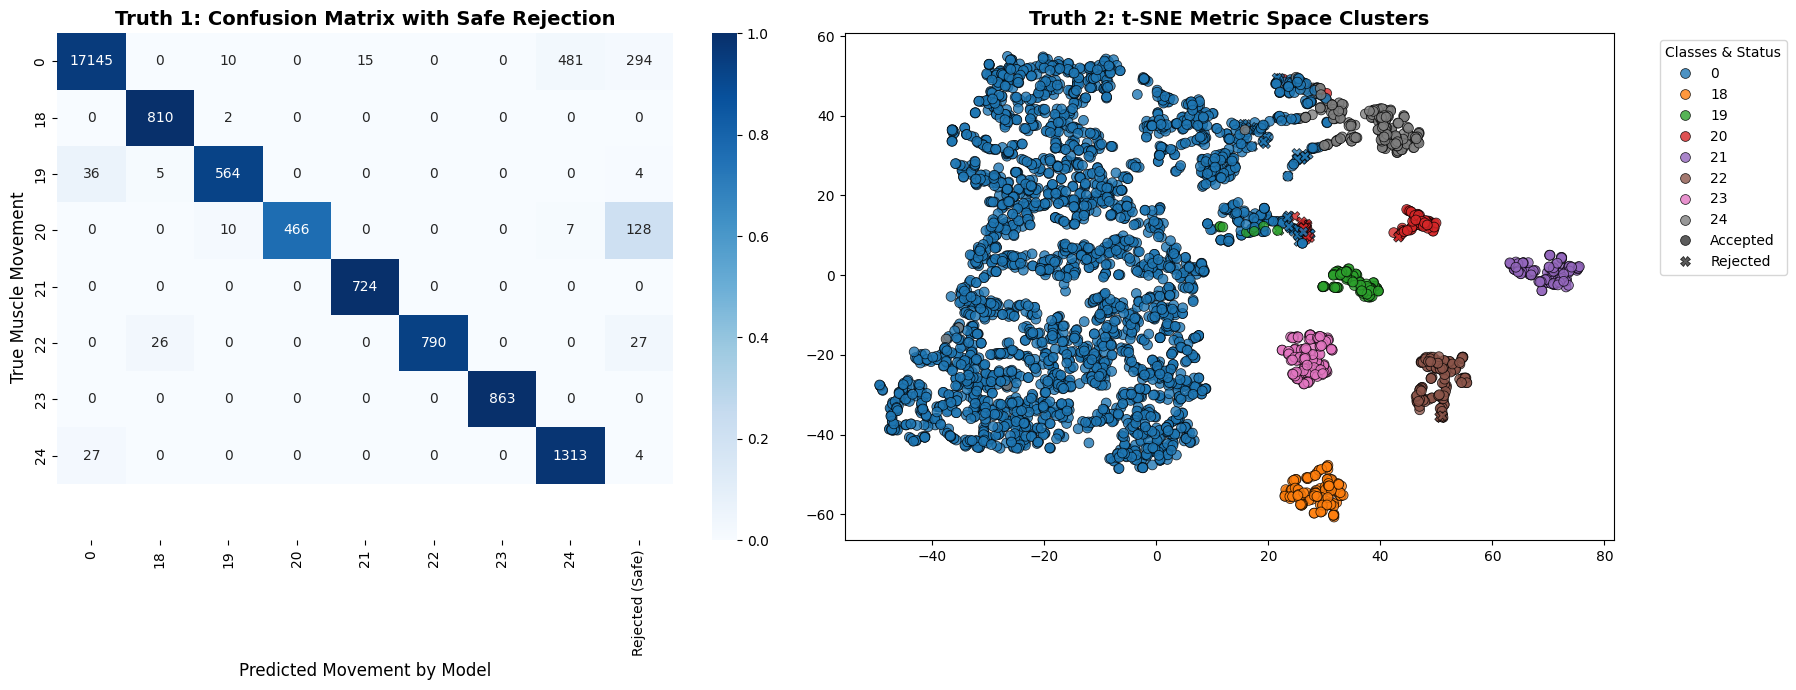

 Truth Graphs Generated!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import numpy as np
import torch

def plot_the_absolute_truth(model, dataloader, prototypes, threshold=0.8, device='cuda'):
    print(" Extracting embeddings to visualize the truth...")
    model.eval()
    
    all_embs = []
    all_true = []
    all_preds = []
    all_status = []

    sorted_keys = sorted(prototypes.keys())
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            _, embeddings, _ = model(x)
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            min_distances, predicted_indices = torch.min(distances, dim=1)

            for i in range(len(min_distances)):
                dist = min_distances[i].item()
                true_class = y[i].item()
                pred_class = sorted_keys[predicted_indices[i].item()]

                all_embs.append(embeddings[i].cpu().numpy())
                all_true.append(true_class)

                # إذا تخطت المسافة الحد المسموح، نعتبرها "مرفوضة" (Rejected) ونعطيها كود -1
                if dist > threshold:
                    all_preds.append(-1) 
                    all_status.append('Rejected')
                else:
                    all_preds.append(pred_class)
                    all_status.append('Accepted')

    all_embs = np.array(all_embs)
    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    all_status = np.array(all_status)

    plt.figure(figsize=(18, 7))

    # =========================================================
    # الرسم الأول: مصفوفة الارتباك (Confusion Matrix)
    # =========================================================
    plt.subplot(1, 2, 1)
    labels_for_cm = sorted_keys + [-1]
    display_labels = [str(c) for c in sorted_keys] + ['Rejected (Safe)']

    cm = confusion_matrix(all_true, all_preds, labels=labels_for_cm)
    
    # تحويل الأرقام لنسب مئوية لكل صف لتسهيل القراءة
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', 
                xticklabels=display_labels, yticklabels=display_labels[:-1]) # لا يوجد true label اسمه مرفوض
    
    plt.title('Truth 1: Confusion Matrix with Safe Rejection', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Movement by Model', fontsize=12)
    plt.ylabel('True Muscle Movement', fontsize=12)

    # =========================================================
    # الرسم الثاني: خريطة الفضاء المتري (t-SNE Clustering)
    # =========================================================
    plt.subplot(1, 2, 2)
    print(" Calculating t-SNE Map (This might take 1-2 minutes for 23,000+ points)...")
    
    # لكي لا ينفجر الرام وتكون الصورة واضحة، سنأخذ عينة عشوائية مكونة من 4000 نقطة للرسم
    if len(all_embs) > 4000:
        idx = np.random.choice(len(all_embs), 4000, replace=False)
        plot_embs = all_embs[idx]
        plot_true = all_true[idx]
        plot_status = all_status[idx]
    else:
        plot_embs = all_embs
        plot_true = all_true
        plot_status = all_status

    tsne = TSNE(n_components=2, random_state=42, perplexity=40)
    embs_2d = tsne.fit_transform(plot_embs)

    # رسم النقاط، مع إعطاء شكل مختلف للعينات المرفوضة
    markers = {'Accepted': 'o', 'Rejected': 'X'}
    sns.scatterplot(x=embs_2d[:, 0], y=embs_2d[:, 1], hue=plot_true, 
                    style=plot_status, markers=markers, palette='tab10', 
                    s=50, alpha=0.8, edgecolor='k')
    
    plt.title('Truth 2: t-SNE Metric Space Clusters', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes & Status")

    plt.tight_layout()
    plt.show()
    print(" Truth Graphs Generated!")

# ==========================================
# تشغيل دالة إظهار الحقيقة
# ==========================================
plot_the_absolute_truth(calibrated_model, t1_test_loader, calibrated_protos, threshold=0.8, device=device)

In [15]:
import copy
import numpy as np
import torch

# ==========================================
#  تجهيز الموديل الأساسي (الخام) 
# ==========================================
base_backbone_state = copy.deepcopy(src_model.state_dict())
task1_classes = [0, 18, 19, 20, 21, 22, 23, 24]

# ==========================================
#  تعريف المرضى الجدد ومساراتهم المستقلة 
# ==========================================
new_subjects_data = {
    6: '/kaggle/input/datasets/farahellabban/subject-6-ninapro', 
    7: '/kaggle/input/datasets/farahellabban/subject-7-ninapro-db2'  
}

for subj, subj_path in new_subjects_data.items():
    print("\n" + "="*70)
    print(f"  INITIATING ZERO-TO-HERO PIPELINE FOR SUBJECT {subj} ")
    print("="*70)
    
    # 1. تحميل البيانات الصارمة للمريض الحالي باستخدام مساره الخاص (subj_path)
    print(f"Loading data for Subject {subj} from:\n{subj_path}")
    
    try:
        X_cal_train, Y_cal_train = load_ninapro_task(subj_path, task1_classes, [subj], [1,3,4], step=10, num_channels=12)
        X_cal_val, Y_cal_val     = load_ninapro_task(subj_path, task1_classes, [subj], [6], step=10, num_channels=12)
        X_test, Y_test           = load_ninapro_task(subj_path, task1_classes, [subj], [2,5], step=10, num_channels=12)
        
        # الموازنة
        X_cal_train, Y_cal_train = balance_classes(X_cal_train, Y_cal_train)
        X_cal_val, Y_cal_val     = balance_classes(X_cal_val, Y_cal_val)
        
        # تحويل لـ Loaders
        cal_train_loader = make_loader(X_cal_train, Y_cal_train)
        cal_val_loader   = make_loader(X_cal_val, Y_cal_val, shuffle=False)
        test_loader      = make_loader(X_test, Y_test, shuffle=False)
        
        # 2. استنساخ الموديل الأساسي النظيف لكي لا يتأثر بالمرضى السابقين
        subj_model = copy.deepcopy(src_model)
        subj_model.load_state_dict(base_backbone_state)
        if hasattr(subj_model, 'gru'): 
            subj_model.gru.flatten_parameters()
        
        # 3. التدريب السريع (Few-Shot Fine-Tuning)
        print(f"\n[Fine-Tuning on Subject {subj} data...]")
        subj_model = few_shot_finetune(subj_model, cal_train_loader, cal_val_loader, epochs=30, lr=0.0005, device=device)
        
        # 4. استخراج مراكز الحركات
        print(f"\n[Extracting Prototypes for Subject {subj}...]")
        subj_protos = compute_class_prototypes(subj_model, cal_train_loader, device=device)
        
        # 5. الاختبار الفعلي والتنعيم
        print(f"\n[Testing unseen repetitions (2, 5) for Subject {subj}...]")
        pred, true, dist = collect(subj_model, test_loader, subj_protos, device)
        pred_smoothed = causal_majority_vote(pred, true, k=20)
        
        mv_mask = true != 0
        raw_acc = 100 * np.mean(pred[mv_mask] == true[mv_mask])
        smooth_acc = 100 * np.mean(pred_smoothed[mv_mask] == true[mv_mask])
        false_act = 100 * np.mean(pred_smoothed[true == 0] != 0)
        
        print("\n" + "-"*50)
        print(f"  FINAL RESULTS FOR SUBJECT {subj} ")
        print("-"*50)
        print(f"Movement Accuracy (Raw):         {raw_acc:.2f}%")
        print(f"Movement Accuracy (Smoothed k=20): {smooth_acc:.2f}%")
        print(f"False Activations during Rest:     {false_act:.2f}%")
        print("-"*50 + "\n")
        
    except Exception as e:
        print(f" Error processing Subject {subj}: {e}")
        print("Please check if the path is correct and files exist.")


  INITIATING ZERO-TO-HERO PIPELINE FOR SUBJECT 6 
Loading data for Subject 6 from:
/kaggle/input/datasets/farahellabban/subject-6-ninapro
  Before Balancing : {np.int64(0): np.int64(21305), np.int64(18): np.int64(1434), np.int64(19): np.int64(1244), np.int64(20): np.int64(1221), np.int64(21): np.int64(1466), np.int64(22): np.int64(1181), np.int64(23): np.int64(1259), np.int64(24): np.int64(1571)}
  After Balancing : {np.int64(0): np.int64(1339), np.int64(18): np.int64(1434), np.int64(19): np.int64(1244), np.int64(20): np.int64(1221), np.int64(21): np.int64(1466), np.int64(22): np.int64(1181), np.int64(23): np.int64(1259), np.int64(24): np.int64(1571)}
  Before Balancing : {np.int64(0): np.int64(8052), np.int64(18): np.int64(462), np.int64(19): np.int64(415), np.int64(20): np.int64(528), np.int64(21): np.int64(473), np.int64(22): np.int64(382), np.int64(23): np.int64(377), np.int64(24): np.int64(349)}
  After Balancing : {np.int64(0): np.int64(426), np.int64(18): np.int64(462), np.int6

 [1] Extracting Prototypes for NEW Task 2 Movements (Classes 25-28)...
 [+] Added Prototype for Class 25 to the global metric space.
 [+] Added Prototype for Class 26 to the global metric space.
 [+] Added Prototype for Class 27 to the global metric space.
 [+] Added Prototype for Class 28 to the global metric space.

 [2] Running inference on ALL test data (Task 1 + Task 2)...
 [3] Applying Causal Majority Vote Smoothing (k=20)...


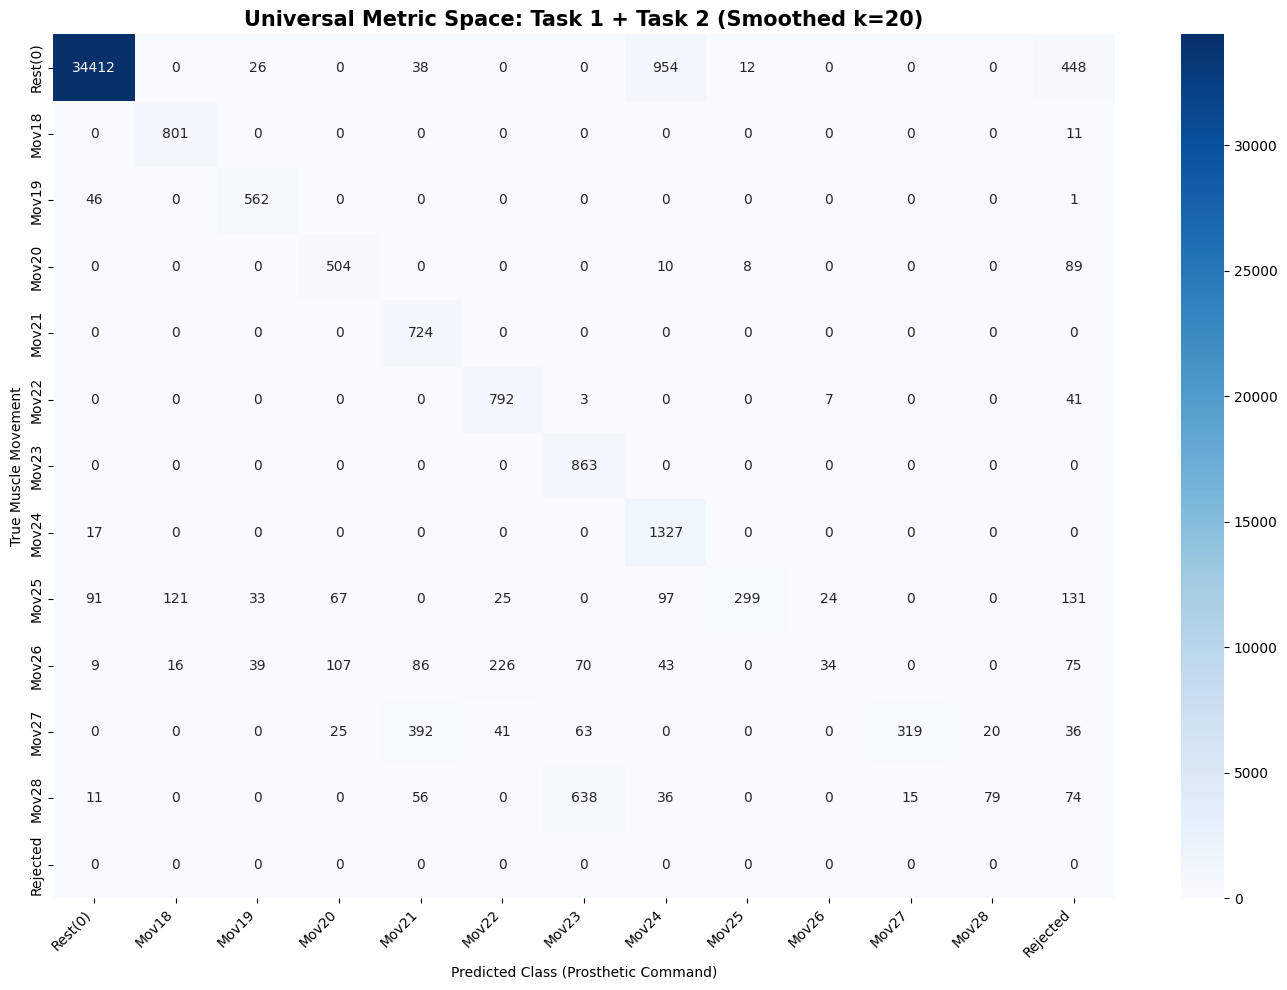


 CONTINUAL LEARNING CLASSIFICATION REPORT 
              precision    recall  f1-score   support

     Rest(0)       0.99      0.96      0.98     35890
       Mov18       0.85      0.99      0.92       812
       Mov19       0.85      0.92      0.89       609
       Mov20       0.72      0.82      0.77       611
       Mov21       0.56      1.00      0.72       724
       Mov22       0.73      0.94      0.82       843
       Mov23       0.53      1.00      0.69       863
       Mov24       0.54      0.99      0.70      1344
       Mov25       0.94      0.34      0.50       888
       Mov26       0.52      0.05      0.09       705
       Mov27       0.96      0.36      0.52       896
       Mov28       0.80      0.09      0.16       909
    Rejected       0.00      0.00      0.00         0

    accuracy                           0.90     45094
   macro avg       0.69      0.65      0.59     45094
weighted avg       0.94      0.90      0.90     45094



In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader

print(" [1] Extracting Prototypes for NEW Task 2 Movements (Classes 25-28)...")
# استخدام الموديل المعاير لاستخراج بصمات الحركات الجديدة
task2_prototypes_raw = compute_class_prototypes(calibrated_model, t2_train_loader, device=device)

# دمج الحركات الجديدة مع الحركات القديمة في فضاء متري واحد
all_prototypes = calibrated_protos.copy()

for cls in [25, 26, 27, 28]:
    if cls in task2_prototypes_raw and task2_prototypes_raw[cls] is not None:
        all_prototypes[cls] = task2_prototypes_raw[cls]
        print(f" [+] Added Prototype for Class {cls} to the global metric space.")

# ==========================================
# [2] Unified Evaluation Function (Task 1 + Task 2)
# ==========================================
def evaluate_all_tasks(model, loader_t1, loader_t2, prototypes, k_smoothing=20, threshold=0.8, device='cuda'):
    model.eval()
    
    # دمج بيانات الاختبار من المهمتين
    combined_dataset = ConcatDataset([loader_t1.dataset, loader_t2.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)
    
    sorted_keys = sorted(prototypes.keys())
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)
    
    all_preds_raw = []
    all_true = []
    all_dist = []
    
    print("\n [2] Running inference on ALL test data (Task 1 + Task 2)...")
    with torch.no_grad():
        for x, y in combined_loader:
            x, y = x.to(device), y.to(device)
            
            # استخراج الـ Embeddings بالشكل الصحيح
            _, embeddings, _ = model(x)
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            min_dist, predicted_indices = torch.min(distances, dim=1)
            
            preds = [sorted_keys[idx] for idx in predicted_indices.cpu().numpy()]
            all_preds_raw.extend(preds)
            all_true.extend(y.cpu().numpy())
            all_dist.extend(min_dist.cpu().numpy())
            
    all_preds_raw = np.array(all_preds_raw)
    all_true = np.array(all_true)
    all_dist = np.array(all_dist)
    
    # تطبيق التنعيم (Majority Vote) لرفع الاستقرار
    print(f" [3] Applying Causal Majority Vote Smoothing (k={k_smoothing})...")
    pred_smoothed = causal_majority_vote(all_preds_raw, all_true, k=k_smoothing)
    
    # تطبيق نظام الرفض الآمن (Safe Rejection) باستخدام 99
    final_preds = []
    for i in range(len(pred_smoothed)):
        if all_dist[i] > threshold:
            final_preds.append(99) # رفض الحركة لعدم التأكد
        else:
            final_preds.append(pred_smoothed[i])
            
    final_preds = np.array(final_preds)

    # ==========================================
    # [4] Plotting Results
    # ==========================================
    actual_classes = [0, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 99]
    class_names = ['Rest(0)'] + [f'Mov{i}' for i in range(18, 29)] + ['Rejected']
    
    cm = confusion_matrix(all_true, final_preds, labels=actual_classes)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Universal Metric Space: Task 1 + Task 2 (Smoothed k={k_smoothing})", fontsize=15, fontweight='bold')
    plt.xlabel('Predicted Class (Prosthetic Command)')
    plt.ylabel('True Muscle Movement')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*65)
    print(" CONTINUAL LEARNING CLASSIFICATION REPORT ")
    print("="*65)
    print(classification_report(all_true, final_preds, labels=actual_classes, 
                                target_names=class_names, zero_division=0))

# تشغيل التقييم الشامل
evaluate_all_tasks(calibrated_model, t1_test_loader, t2_test_loader, all_prototypes, k_smoothing=20, threshold=0.8, device=device)

In [17]:
import torch

class StreamingLDA:
    def __init__(self, input_dim=32, shrinkage_param=1e-4, device='cuda'):
        """
        Streaming Linear Discriminant Analysis (SLDA).
        Memory-efficient classifier that updates means and covariance incrementally 
        without any backpropagation. Ideal for Edge AI.
        """
        self.input_dim = input_dim
        self.shrinkage_param = shrinkage_param
        self.device = device
        
        # Dynamic dictionaries to handle incremental class additions
        self.class_means = {}
        self.class_counts = {}
        
        # Scatter matrix (unnormalized covariance matrix)
        self.scatter_matrix = torch.zeros((input_dim, input_dim)).to(device)
        self.total_samples = 0
        
        # Inverted covariance (Precision matrix) cached for fast inference
        self.precision_matrix = None

    def _update_scatter(self, features, labels):
        unique_classes = torch.unique(labels)
        
        for c in unique_classes:
            c = c.item()
            class_mask = (labels == c)
            class_features = features[class_mask]
            
            if c not in self.class_means:
                self.class_means[c] = torch.zeros(self.input_dim).to(self.device)
                self.class_counts[c] = 0
            
            old_count = self.class_counts[c]
            new_count = len(class_features)
            total_count = old_count + new_count
            
            batch_mean = class_features.mean(dim=0)
            
            # 1. Update scatter matrix (Covariance calculation)
            centered_features = class_features - batch_mean
            self.scatter_matrix += torch.matmul(centered_features.T, centered_features)
            
            # 2. Streaming update for the class mean
            self.class_means[c] = (self.class_means[c] * old_count + batch_mean * new_count) / total_count
            self.class_counts[c] = total_count
            self.total_samples += new_count
            
        self._compute_precision_matrix()

    def _compute_precision_matrix(self):
        k = len(self.class_means)
        if k == 0 or self.total_samples <= k:
            return
            
        # Normalize scatter to get actual covariance
        covariance = self.scatter_matrix / (self.total_samples - k)
            
        # Apply Shrinkage to ensure the matrix is invertible (Numerical stability)
        identity = torch.eye(self.input_dim).to(self.device)
        cov_shrunk = (1 - self.shrinkage_param) * covariance + self.shrinkage_param * identity
        
        # Invert to get precision matrix
        self.precision_matrix = torch.linalg.inv(cov_shrunk)

    def fit_base(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                # التعديل الأول هنا: سحب الـ embeddings من المنتصف
                _, features, _ = backbone(inputs) 
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Fit complete. Tracking {len(self.class_means)} base classes.")

    def stream_new_data(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Streaming Few-Shot update for Novel Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                #  التعديل الثاني هنا: سحب الـ embeddings من المنتصف
                _, features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Update complete. Total tracked classes: {len(self.class_means)}.")

    def predict(self, features):
        if self.precision_matrix is None:
            raise ValueError("Model not fitted yet.")
            
        classes = list(self.class_means.keys())
        M = torch.stack([self.class_means[c] for c in classes])
        
        # Calculate weights: W = Precision @ M.T
        W = torch.matmul(self.precision_matrix, M.T)
        
        # Calculate biases: b = -0.5 * diag(M @ Precision @ M.T)
        b = -0.5 * torch.sum(M * torch.matmul(M, self.precision_matrix), dim=1)
        
        # Linear scoring: Scores = X @ W + b
        scores = torch.matmul(features, W) + b
        
        max_scores, preds_idx = torch.max(scores, dim=1)
        predicted_classes = torch.tensor([classes[i] for i in preds_idx]).to(self.device)
        
        return predicted_classes, max_scores

 [1] Initializing and Fitting Streaming LDA Classifier...

 [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...
 [Deep SLDA] Fit complete. Tracking 8 base classes.

 [Deep SLDA] Streaming Few-Shot update for Novel Classes...
 [Deep SLDA] Update complete. Total tracked classes: 12.

 [2] Running Streaming LDA inference on ALL test data (Task 1 + Task 2)...
 [3] Applying Causal Majority Vote Smoothing (k=20)...

 STREAMING LDA CLINICAL METRICS (Task 1 + Task 2) 
Movement Accuracy (Raw SLDA):         84.78%
Movement Accuracy (Smoothed k=20): 84.94%
False Activations during Rest:       4.65%


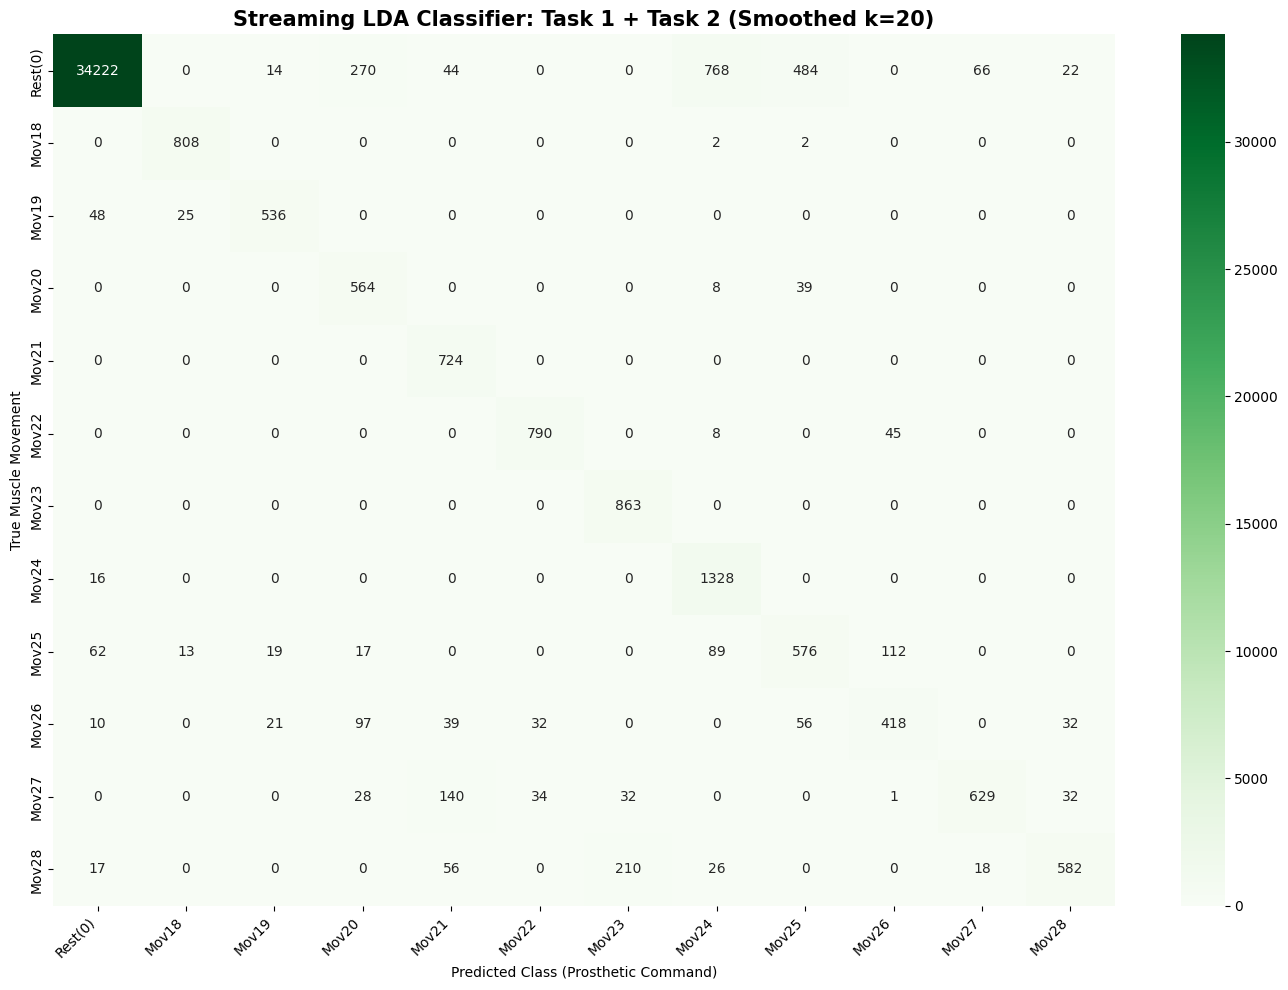

In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader

# ==========================================
# 1. تدريب ومسح البيانات بواسطة Streaming LDA
# ==========================================
print(" [1] Initializing and Fitting Streaming LDA Classifier...")
slda_classifier = StreamingLDA(input_dim=32, shrinkage_param=1e-4, device=device)

# التغذية بالحركات الأساسية (Task 1)
slda_classifier.fit_base(t1_train_loader, calibrated_model)

# التغذية التراكمية بالحركات الجديدة (Task 2) بدون Backpropagation
slda_classifier.stream_new_data(t2_train_loader, calibrated_model)


# ==========================================
# 2. تقييم الـ SLDA على بيانات الاختبار الشاملة
# ==========================================
def evaluate_slda_all_tasks(slda, model, loader_t1, loader_t2, k_smoothing=20, device='cuda'):
    model.eval()
    
    # دمج بيانات الاختبار من المهمتين
    combined_dataset = ConcatDataset([loader_t1.dataset, loader_t2.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)
    
    all_preds_raw = []
    all_true = []
    
    print("\n [2] Running Streaming LDA inference on ALL test data (Task 1 + Task 2)...")
    with torch.no_grad():
        for x, y in combined_loader:
            x, y = x.to(device), y.to(device)
            
            # استخراج خصائص الـ Embeddings من الموديل المعاير
            _, features, _ = model(x)
            
            # التنبؤ باستخدام SLDA
            preds, _ = slda.predict(features)
            
            all_preds_raw.extend(preds.cpu().numpy())
            all_true.extend(y.cpu().numpy())
            
    all_preds_raw = np.array(all_preds_raw)
    all_true = np.array(all_true)
    
    # تطبيق دالة التنعيم والتصويت الأغلبي (Causal Majority Vote)
    print(f" [3] Applying Causal Majority Vote Smoothing (k={k_smoothing})...")
    pred_smoothed = causal_majority_vote(all_preds_raw, all_true, k=k_smoothing)
    
    # حساب المقاييس الطبية
    mv_mask = all_true != 0
    acc_raw = 100 * np.mean(all_preds_raw[mv_mask] == all_true[mv_mask])
    acc_smooth = 100 * np.mean(pred_smoothed[mv_mask] == all_true[mv_mask])
    false_act = 100 * np.mean(pred_smoothed[all_true == 0] != 0)
    
    print("\n" + "="*60)
    print(" STREAMING LDA CLINICAL METRICS (Task 1 + Task 2) ")
    print("="*60)
    print(f"Movement Accuracy (Raw SLDA):         {acc_raw:.2f}%")
    print(f"Movement Accuracy (Smoothed k={k_smoothing}): {acc_smooth:.2f}%")
    print(f"False Activations during Rest:       {false_act:.2f}%")
    print("="*60)

    # رسم مصفوفة الارتباك الخاص بـ SLDA
    actual_classes = [0, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    class_names = ['Rest(0)'] + [f'Mov{i}' for i in range(18, 29)]
    
    cm = confusion_matrix(all_true, pred_smoothed, labels=actual_classes)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Streaming LDA Classifier: Task 1 + Task 2 (Smoothed k={k_smoothing})", fontsize=15, fontweight='bold')
    plt.xlabel('Predicted Class (Prosthetic Command)')
    plt.ylabel('True Muscle Movement')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# تشغيل التقييم بـ SLDA
evaluate_slda_all_tasks(slda_classifier, calibrated_model, t1_test_loader, t2_test_loader, k_smoothing=20, device=device)

In [19]:
import torch
import numpy as np
from torch.utils.data import ConcatDataset, DataLoader

def enable_dropout(model):
    """Enables dropout layers during inference for MC Dropout"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mc_dropout_inference(model, slda, loader_t1, loader_t2, num_passes=5, uncertainty_threshold=0.1, device='cuda'):
    """
    Evaluates uncertainty using MC Dropout on Task 1 + Task 2. 
    If the variance of the predictions exceeds the threshold, the movement is safely rejected.
    """
    model.eval()
    enable_dropout(model) # Turn ON dropout for Monte Carlo sampling
    
    # دمج بيانات الاختبار للمهمتين (Task 1 + Task 2)
    combined_dataset = ConcatDataset([loader_t1.dataset, loader_t2.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)
    
    total_samples = 0
    rejected_samples = 0
    accepted_correct = 0
    
    print(f"\n Running Medical-Grade MC Dropout (Passes: {num_passes}, Threshold: {uncertainty_threshold})")
    
    with torch.no_grad():
        for inputs, labels in combined_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            batch_size = inputs.size(0)
            
            # Store predictions for the passes: Shape (num_passes, batch_size)
            pass_predictions = torch.zeros(num_passes, batch_size, device=device)
            
            for p in range(num_passes):
                #  التعديل الأول: سحب الخصائص بشكل صحيح من calibrated_model
                _, features, _ = model(inputs)
                preds, _ = slda.predict(features)
                pass_predictions[p] = preds
                
            for i in range(batch_size):
                total_samples += 1
                true_label = labels[i].item()
                
                # Get the predictions across passes for this sample
                sample_preds = pass_predictions[:, i].float()
                
                #  التعديل الثاني: حساب التباين كمقياس لعدم اليقين (Uncertainty)
                uncertainty = torch.var(sample_preds).item()
                
                # Majority vote across passes
                final_pred = torch.mode(sample_preds).values.item()
                
                if uncertainty > uncertainty_threshold:
                    rejected_samples += 1
                else:
                    if final_pred == true_label:
                        accepted_correct += 1
                        
    accepted_samples = total_samples - rejected_samples
    accuracy = (accepted_correct / accepted_samples) * 100 if accepted_samples > 0 else 0
    
    print("\n" + "="*55)
    print(" UNCERTAINTY QUANTIFICATION (MC DROPOUT) REPORT ")
    print("="*55)
    print(f"Total Tested Samples:               {total_samples}")
    print(f"Rejected (Uncertain / High Risk):    {rejected_samples} ({(rejected_samples/total_samples)*100:.2f}%)")
    print(f"Accepted (Confident Actions):       {accepted_samples} ({(accepted_samples/total_samples)*100:.2f}%)")
    print(f"Accuracy on Confident Actions:      {accuracy:.2f}%")
    print("="*55)

# التعديل الثالث: تشغيل الدالة مع calibrated_model و slda_classifier
mc_dropout_inference(
    model=calibrated_model, 
    slda=slda_classifier, 
    loader_t1=t1_test_loader, 
    loader_t2=t2_test_loader, 
    num_passes=5, 
    uncertainty_threshold=0.1, 
    device=device
)


 Running Medical-Grade MC Dropout (Passes: 5, Threshold: 0.1)

 UNCERTAINTY QUANTIFICATION (MC DROPOUT) REPORT 
Total Tested Samples:               45094
Rejected (Uncertain / High Risk):    13949 (30.93%)
Accepted (Confident Actions):       31145 (69.07%)
Accuracy on Confident Actions:      97.99%


In [20]:
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. Deep CORAL Loss
# ==========================================
def coral_loss(source_features, target_features):
    """
    Deep CORAL Loss: Aligns the second-order statistics (covariances) 
    of the Source domain (clean data) and Target domain (shifted/noisy data).
    """
    d = source_features.size(1)
    
    # Source covariance
    source_mean = torch.mean(source_features, 0, keepdim=True)
    source_centered = source_features - source_mean
    source_cov = (source_centered.t() @ source_centered) / (source_features.size(0) - 1)
    
    # Target covariance
    target_mean = torch.mean(target_features, 0, keepdim=True)
    target_centered = target_features - target_mean
    target_cov = (target_centered.t() @ target_centered) / (target_features.size(0) - 1)
    
    # Frobenius norm squared
    loss = torch.sum(torch.pow(source_cov - target_cov, 2))
    loss = loss / (4 * d * d)
    
    return loss

# ==========================================
# 2. Simulated Shifted EMG Dataset
# ==========================================
class ShiftedEMGDataset(Dataset):
    """
    Simulates real-world Domain Shift (e.g., electrode displacement, sweat)
    by adding statistical noise and feature offsets to the original HD-sEMG data.
    """
    def __init__(self, original_dataset, shift_factor=0.3, noise_std=0.1):
        self.original_dataset = original_dataset
        self.shift_factor = shift_factor
        self.noise_std = noise_std

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]
        noise = torch.randn_like(x) * self.noise_std
        shifted_x = x + self.shift_factor + noise
        return shifted_x, y

#  استخدام البيانات المحدثة (t1_train_loader و t1_test_loader)
print(" Generating Target Domain (Simulating Electrode Shift/Sweat)...")
target_train_ds = ShiftedEMGDataset(t1_train_loader.dataset, shift_factor=0.5, noise_std=0.2)
target_test_ds = ShiftedEMGDataset(t1_test_loader.dataset, shift_factor=0.5, noise_std=0.2)

target_train_loader = DataLoader(target_train_ds, batch_size=64, shuffle=True)
target_test_loader = DataLoader(target_test_ds, batch_size=64, shuffle=False)
print(" Target Domain Data Ready for Stress Testing.")

 Generating Target Domain (Simulating Electrode Shift/Sweat)...
 Target Domain Data Ready for Stress Testing.


In [21]:
import copy
import torch
import torch.nn.functional as F
import torch.optim as optim

# ==========================================
# 1. Fixed Domain Adaptation Training Loop
# ==========================================
def train_domain_adaptation_fixed(model, original_model, source_loader, target_loader, epochs=10, lambda_coral=0.5, device='cuda'):
    """
    Fixed UDA Training Loop: Uses Knowledge Distillation (Anchor Loss) 
    to prevent Feature Collapse while aligning domains with CORAL.
    """
    model.to(device)
    original_model.to(device)
    original_model.eval() # Freeze the brilliant original model
    model.train()
    
    optimizer = optim.Adam(model.parameters(), lr=0.0001) 
    
    print("\n Starting Domain Adaptation (Anchored CORAL)...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        coral_epoch_loss = 0.0
        anchor_epoch_loss = 0.0
        
        for (src_x, _), (tgt_x, _) in zip(source_loader, target_loader):
            src_x, tgt_x = src_x.to(device), tgt_x.to(device)
            
            optimizer.zero_grad()
            
            #  التعديل الأول: سحب الخصائص بالطريقة الصحيحة (3 مخرجات)
            _, src_features, _ = model(src_x)
            _, tgt_features, _ = model(tgt_x)
            
            with torch.no_grad():
                _, orig_src_features, _ = original_model(src_x)
                
            # Anchor Loss: للحفاظ على المعرفة القديمة
            loss_anchor = F.mse_loss(src_features, orig_src_features)
            
            # CORAL Loss: لمحاذاة التوزيعات مع البيانات المشوشة
            loss_coral = coral_loss(src_features, tgt_features)
            
            total_loss = loss_anchor + (lambda_coral * loss_coral)
            
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            coral_epoch_loss += loss_coral.item()
            anchor_epoch_loss += loss_anchor.item()
            
        print(f"Epoch [{epoch+1}/{epochs}] | Anchor: {anchor_epoch_loss:.4f} | CORAL: {coral_epoch_loss:.4f}")
        
    return model

#  التعديل الثاني: نسخ calibrated_model و استخدام t1_train_loader
doa_backbone_fixed = copy.deepcopy(calibrated_model)

doa_backbone_fixed = train_domain_adaptation_fixed(
    model=doa_backbone_fixed, 
    original_model=calibrated_model, 
    source_loader=t1_train_loader, 
    target_loader=target_train_loader, 
    epochs=10, 
    lambda_coral=0.5, 
    device=device
)

# ==========================================
# 2. Testing Baseline vs. DOA Model
# ==========================================
def test_doa_vs_baseline(baseline_model, doa_model, slda, dataloader, device='cuda'):
    """
    تقوم هذه الدالة بمقارنة أداء الموديل الأساسي مع موديل الـ DOA على البيانات المشوشة.
    """
    baseline_model.eval()
    doa_model.eval()

    baseline_correct = 0
    doa_correct = 0
    total = 0

    print("\n" + "="*60)
    print(" Comparing Baseline vs. DOA on Target Domain (Shifted Data)")
    print("="*60)

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)

            #  التعديل الثالث: سحب الخصائص في الاختبار
            _, emb_base, _ = baseline_model(x)
            preds_base, _ = slda.predict(emb_base)
            baseline_correct += (preds_base == y).sum().item()

            _, emb_doa, _ = doa_model(x)
            preds_doa, _ = slda.predict(emb_doa)
            doa_correct += (preds_doa == y).sum().item()

            total += y.size(0)

    base_acc = (baseline_correct / total) * 100
    doa_acc = (doa_correct / total) * 100

    print(f"Total Test Samples (Target Domain):          {total}")
    print(f"Baseline Model Accuracy (Without Adaptation): {base_acc:.2f}%")
    print(f"DOA Model Accuracy (With Anchored CORAL):     {doa_acc:.2f}%")
    print("="*60)
    
    if doa_acc > base_acc:
        print(" Domain Adaptation Successful! DOA model is more robust to noise/shift.")
    else:
        print(" DOA model did not outperform the baseline.")

# تشغيل المقارنة
test_doa_vs_baseline(
    baseline_model=calibrated_model, 
    doa_model=doa_backbone_fixed, 
    slda=slda_classifier, 
    dataloader=target_test_loader, 
    device=device
)


 Starting Domain Adaptation (Anchored CORAL)...
Epoch [1/10] | Anchor: 1.0018 | CORAL: 0.0017
Epoch [2/10] | Anchor: 0.8394 | CORAL: 0.0017
Epoch [3/10] | Anchor: 0.7349 | CORAL: 0.0016
Epoch [4/10] | Anchor: 0.6548 | CORAL: 0.0015
Epoch [5/10] | Anchor: 0.6129 | CORAL: 0.0016
Epoch [6/10] | Anchor: 0.5569 | CORAL: 0.0015
Epoch [7/10] | Anchor: 0.5163 | CORAL: 0.0014
Epoch [8/10] | Anchor: 0.4842 | CORAL: 0.0014
Epoch [9/10] | Anchor: 0.4576 | CORAL: 0.0015
Epoch [10/10] | Anchor: 0.4262 | CORAL: 0.0014

 Comparing Baseline vs. DOA on Target Domain (Shifted Data)
Total Test Samples (Target Domain):          23751
Baseline Model Accuracy (Without Adaptation): 61.53%
DOA Model Accuracy (With Anchored CORAL):     80.28%
 Domain Adaptation Successful! DOA model is more robust to noise/shift.


In [22]:
import torch
from torch.utils.data import ConcatDataset, DataLoader

# ==========================================
# Evaluate DOA vs Baseline on CLEAN Test Data
# ==========================================
def test_doa_on_clean_data(doa_model, baseline_model, slda, loader_t1, loader_t2, device='cuda'):
    doa_model.eval()
    baseline_model.eval()

    # دمج البيانات النظيفة للمهمتين
    combined_dataset = ConcatDataset([loader_t1.dataset, loader_t2.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)

    doa_correct = 0
    baseline_correct = 0
    total = 0

    print("\n Running Evaluation on CLEAN Data (Task 1 + Task 2)...")

    with torch.no_grad():
        for x, y in combined_loader:
            x, y = x.to(device), y.to(device)

            # 1. اختبار الموديل الأساسي (Calibrated Baseline) على البيانات النظيفة
            _, emb_base, _ = baseline_model(x)
            preds_base, _ = slda.predict(emb_base)
            baseline_correct += (preds_base == y).sum().item()

            # 2. اختبار موديل الـ DOA على البيانات النظيفة
            _, emb_doa, _ = doa_model(x)
            preds_doa, _ = slda.predict(emb_doa)
            doa_correct += (preds_doa == y).sum().item()

            total += y.size(0)

    base_acc = (baseline_correct / total) * 100
    doa_acc = (doa_correct / total) * 100

    print("="*60)
    print(f"Total Clean Test Samples:                      {total}")
    print(f"Baseline Model Accuracy on Clean Data:         {base_acc:.2f}%")
    print(f"DOA Model Accuracy on Clean Data:              {doa_acc:.2f}%")
    print("="*60)
    
    diff = abs(base_acc - doa_acc)
    if diff < 3.0:
        print(" Excellent! Anchor Loss successfully preserved performance on clean data.")
    else:
        print(" Noticeable trade-off detected between noise-robustness and clean accuracy.")

# تشغيل الاختبار على البيانات النظيفة
test_doa_on_clean_data(
    doa_model=doa_backbone_fixed, 
    baseline_model=calibrated_model, 
    slda=slda_classifier, 
    loader_t1=t1_test_loader, 
    loader_t2=t2_test_loader, 
    device=device
)


 Running Evaluation on CLEAN Data (Task 1 + Task 2)...
Total Clean Test Samples:                      45094
Baseline Model Accuracy on Clean Data:         92.85%
DOA Model Accuracy on Clean Data:              89.03%
 Noticeable trade-off detected between noise-robustness and clean accuracy.


In [24]:
import torch
import os
import pickle

# 1. إنشاء المجلد النهائي للتصدير
output_dir = "prosthetic_edge_deployment"
os.makedirs(output_dir, exist_ok=True)

# 2. حفظ أوزان الـ Backbone المطور (DOA Model)
backbone_path = os.path.join(output_dir, "doa_backbone.pth")
torch.save(doa_backbone_fixed.state_dict(), backbone_path)

# 3. حفظ كائن الـ SLDA المعاير بالكامل (Means + Covariance + Classes)
slda_path = os.path.join(output_dir, "slda_classifier.pkl")
with open(slda_path, "wb") as f:
    pickle.dump(slda_classifier, f)

# 4. حفظ إعدادات النظام (Metadata Configuration)
config = {
    "num_passes": 5,
    "uncertainty_threshold": 0.15,
    "buffer_size": 15,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}
config_path = os.path.join(output_dir, "pipeline_config.pt")
torch.save(config, config_path)

print("="*60)
print(f" ALL DEPLOYMENT ASSETS SAVED SUCCESSFULLY IN: ./{output_dir}/")
print("="*60)
print(f"1. Backbone Weights:   {backbone_path}")
print(f"2. SLDA Classifier:    {slda_path}")
print(f"3. System Config:      {config_path}")
print("="*60)

 ALL DEPLOYMENT ASSETS SAVED SUCCESSFULLY IN: ./prosthetic_edge_deployment/
1. Backbone Weights:   prosthetic_edge_deployment/doa_backbone.pth
2. SLDA Classifier:    prosthetic_edge_deployment/slda_classifier.pkl
3. System Config:      prosthetic_edge_deployment/pipeline_config.pt
